# 02 - Data Quality and Feature Engineering

## Definition
Feature engineering translates raw loan records into risk-relevant signals.

## Theory
Raw variables are often weak predictors in isolation. Ratios, interaction terms, and domain scores capture borrower stress and recoverability.

## Financial + business intuition
Collections teams act on burden, delinquency severity, and collateral strength, not just raw income or loan amount.


## Definition
Feature engineering converts raw borrower and loan records into risk-relevant explanatory signals.

## Theory
This section explains the statistical or ML theory behind the technique and why it is useful in credit recovery operations.

## Mathematical Intuition
We translate the idea into score/probability/ranking logic so each metric can be interpreted quantitatively.

## Financial Intuition
We connect the method to borrower affordability, delinquency severity, collateral protection, and expected recoverable cashflows.

## Business Impact
We explain what this enables for collection managers, risk teams, and executives.

## Real-World Example
A borrower with low EMI-to-income and high collateral coverage is usually easier to recover.

## Visual Explanation
Charts in this notebook show how model/segment behavior changes across borrower groups.

## Code Explanation
Every code cell below is paired with interpretation so beginners can connect implementation details to business outcomes.

## Interpretation of Results
We summarize what changed, why it matters, and how to act on it.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.loan_recovery import (
    DATA_PATH,
    FIGURES_DIR,
    MODELS_DIR,
    TABLES_DIR,
    REPORTS_DIR,
    LoanDataLoader,
    FeatureEngineer,
    LoanEDA,
    BorrowerSegmenter,
    ModelTrainer,
    ModelEvaluator,
    RecoveryStrategyEngine,
    ModelExplainer,
    DashboardBuilder,
    LazyPredictBenchmark,
    PyCaretWorkflow,
    FLAMLOptimizer,
    SmartLoanRecoveryPipeline,
    load_model,
)

sns.set_theme(style="whitegrid")


In [2]:
def ensure_pipeline_artifacts() -> None:
    required = [
        TABLES_DIR / "manual_model_leaderboard.csv",
        TABLES_DIR / "feature_enriched_data.csv",
        MODELS_DIR / "best_manual_model.joblib",
    ]
    if not all(path.exists() for path in required):
        pipeline = SmartLoanRecoveryPipeline(data_path=DATA_PATH, random_state=42)
        pipeline.run()

ensure_pipeline_artifacts()


In [3]:
df = LoanDataLoader(DATA_PATH).load()
fe = FeatureEngineer()
enriched = fe.engineer(df)
print(enriched.shape)
display(enriched.head())


(500, 34)


,Borrower_ID,Age,Monthly_Income,Loan_Amount,Loan_Term_Months,Interest_Rate,Credit_Score,Days_Past_Due,Missed_Payments,Employment_Status,...,EMI_to_Income_Ratio,Debt_Burden_Score,Collateral_Coverage_Ratio,Recovery_Efficiency_Ratio,Risk_Exposure_Score,Missed_Payment_Severity,Delinquency_Score,Recovery_Difficulty_Index,Collection_Intensity_Score,Behavioral_Risk_Score
0,BOR0000,60,6611,47563,60,3.893159,510,244,20,Unemployed,...,0.132152,0.273909,0.268667,1.464500,17.040972,1.833753,0.895000,0.952750,0.021898,1.000000
1,BOR0001,50,13279,12561,12,14.846969,400,29,13,Retired,...,0.085310,0.362067,0.641259,2.527879,16.257880,3.684630,0.530556,0.644956,0.050847,0.681667
2,BOR0002,36,4839,13258,36,4.914164,431,121,4,Employed,...,0.082009,0.195181,1.520470,0.811538,11.068432,0.533780,0.570611,0.371866,0.079470,0.368333
3,BOR0003,64,10527,21616,24,6.158005,680,124,5,Unemployed,...,0.091154,0.480764,3.354045,0.762747,14.736852,1.005899,0.479444,0.401256,0.077922,0.548333
4,BOR0004,29,7878,31734,36,4.094514,431,36,5,Employed,...,0.119097,0.176097,0.826573,1.679510,12.587603,0.501516,0.359500,0.440140,0.075758,0.335000


## Engineered Features (with business purpose)
- `Loan_to_Income_Ratio`: affordability pressure
- `Debt_Burden_Score`: repayment stress
- `Collateral_Coverage_Ratio`: lender protection buffer
- `Recovery_Efficiency_Ratio`: outstanding value per collection attempt
- `EMI_to_Income_Ratio`: monthly installment stress
- `Risk_Exposure_Score`: expected risk-weighted exposure
- `Missed_Payment_Severity`: delinquency intensity
- `Delinquency_Score`: normalized delay risk
- `Recovery_Difficulty_Index`: combined recoverability friction
- `Collection_Intensity_Score`: engagement intensity
- `Behavioral_Risk_Score`: repayment behavior health


In [4]:
engineered_cols = [
    "Loan_to_Income_Ratio",
    "Debt_Burden_Score",
    "Collateral_Coverage_Ratio",
    "Recovery_Efficiency_Ratio",
    "EMI_to_Income_Ratio",
    "Risk_Exposure_Score",
    "Missed_Payment_Severity",
    "Delinquency_Score",
    "Recovery_Difficulty_Index",
    "Collection_Intensity_Score",
    "Behavioral_Risk_Score",
]
display(enriched[engineered_cols + ["Recovery_Status"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
Loan_to_Income_Ratio,500.0,0.339916,0.286439,0.028277,0.148379,0.258878,0.439135,1.742617
Debt_Burden_Score,500.0,0.327031,0.140296,0.066395,0.224103,0.325036,0.426212,1.139569
Collateral_Coverage_Ratio,500.0,8.438044,40.653537,0.000771,0.847729,1.836125,4.025093,670.328358
Recovery_Efficiency_Ratio,500.0,2.075815,2.358185,0.300335,0.771102,1.107478,2.306221,10.552160
EMI_to_Income_Ratio,500.0,0.167532,0.187646,0.006655,0.055769,0.108770,0.213486,1.710219
Risk_Exposure_Score,500.0,13.482172,2.806869,5.375933,11.275808,13.446970,15.663894,19.174371
Missed_Payment_Severity,500.0,2.083912,2.178557,0.000000,0.686367,1.457227,2.639236,11.172146
Delinquency_Score,500.0,0.653870,0.204030,0.113500,0.508569,0.664806,0.811250,1.000000
Recovery_Difficulty_Index,500.0,0.526275,0.162377,0.067184,0.417110,0.525865,0.635650,0.972170
Collection_Intensity_Score,500.0,0.053472,0.062236,0.000000,0.017857,0.035651,0.064396,0.406250


,Recovery_Status
Recovery_Efficiency_Ratio,-0.023720
Recovery_Difficulty_Index,-0.006939
Risk_Exposure_Score,0.014742
Delinquency_Score,0.016461
Missed_Payment_Severity,0.017961
Collection_Intensity_Score,0.020407
Behavioral_Risk_Score,0.022869
Collateral_Coverage_Ratio,0.037006
EMI_to_Income_Ratio,0.052852
Loan_to_Income_Ratio,0.058564


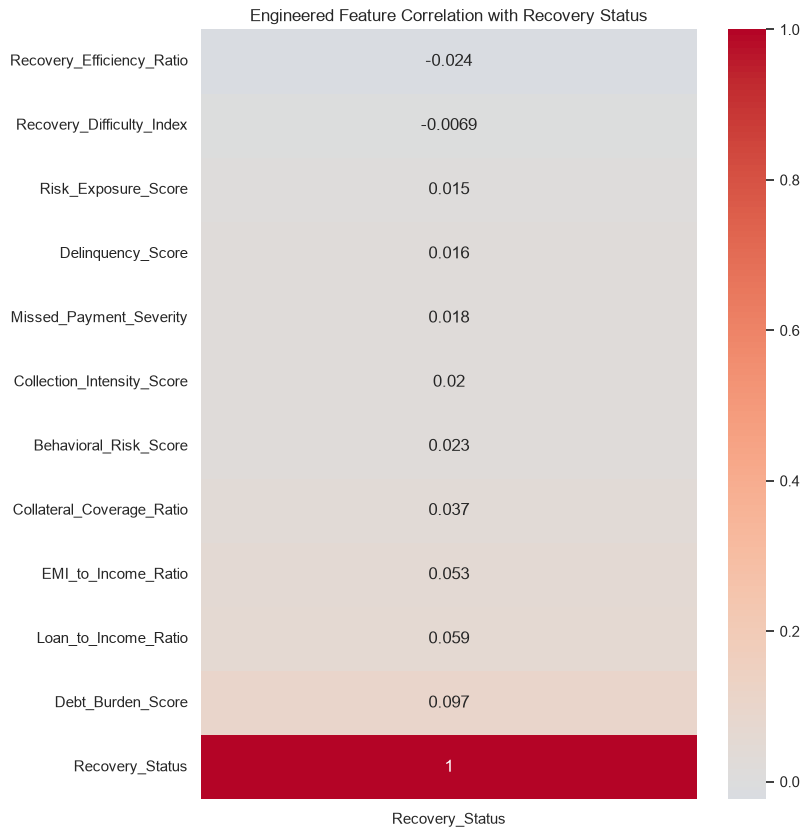

In [5]:
corr = enriched[engineered_cols + ["Recovery_Status"]].corr()[["Recovery_Status"]].sort_values("Recovery_Status")
display(corr)

plt.figure(figsize=(8, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Engineered Feature Correlation with Recovery Status")
plt.show()


## Interpretation
The strongest engineered features should be reused in segmentation, risk scoring, and strategy assignment to keep business logic consistent.
